In [86]:
# Choosing dataset
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 
import numpy as np
dataset = sns.load_dataset('penguins')

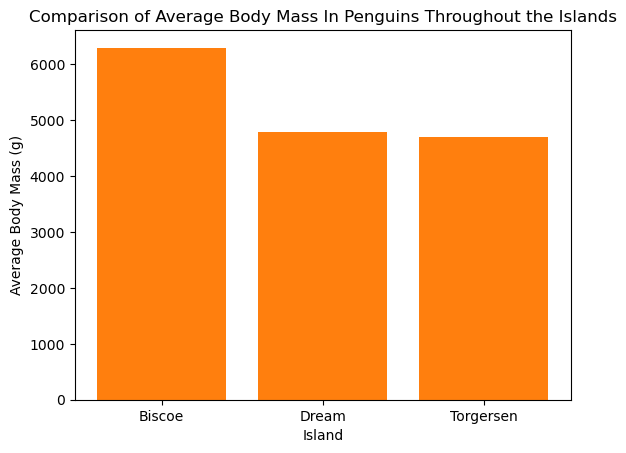

In [87]:
# Task 1 : Bar Chart: Compare a Category
dataset.dropna(inplace=True)
changed = dataset.groupby('island').mean('body_mass_g').reset_index()
plt.bar(changed['island'], changed['body_mass_g'])
plt.bar(y,x)

plt.xlabel("Island")
plt.ylabel("Average Body Mass (g)")
plt.title("Comparison of Average Body Mass In Penguins Throughout the Islands")
plt.show()

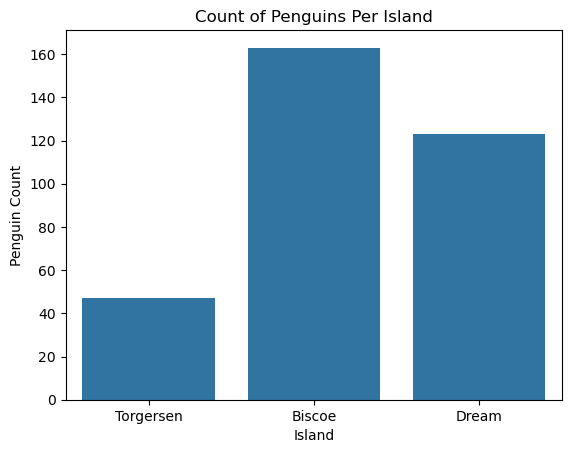

In [88]:
# Task 2 : Count Plot: Category Frequency
sns.countplot(x='island',data=dataset)
plt.xlabel('Island')
plt.ylabel('Penguin Count')
plt.title("Count of Penguins Per Island")
plt.show()

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

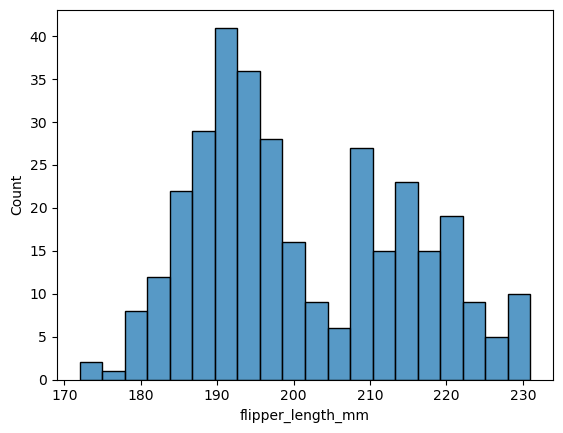

In [89]:
# Task 3 : Histogram: Distribution Shape
sns.histplot(data=dataset, x='flipper_length_mm', bins=20)

# This is right skewed since tail extends toward the higher values on the right

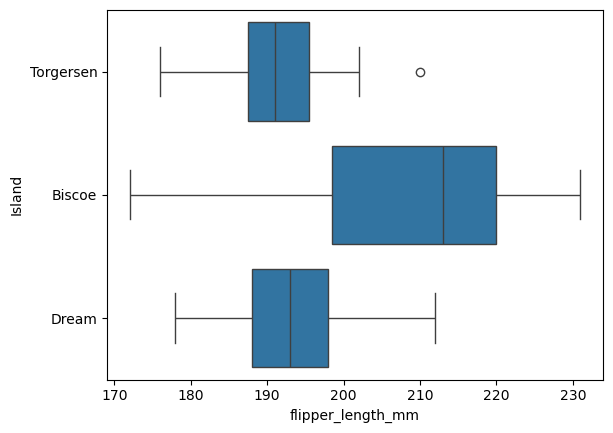

In [90]:
# Task 4 : Box Plot: Visual Outlier Detection
sns.boxplot(data=dataset, x='flipper_length_mm', y='island')
plt.ylabel("Island")
plt.show()

# There is one outlier in Torgersen Island where there is a penguin which has 'flipper_length_mm' of about 210mm which is different from rest of pengins
# in Torgersen

In [91]:
# Task 5 : Outlier Detection: The Mechanism (IQR)
torgersen_dataset = dataset[dataset.island == 'Torgersen']
Q1 = torgersen_dataset['flipper_length_mm'].quantile(0.25)
Q3 = torgersen_dataset['flipper_length_mm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = torgersen_dataset[(torgersen_dataset['flipper_length_mm'] < lower) | (torgersen_dataset['flipper_length_mm'] > upper)]
print("Outliers in Torgersen Island: ", len(outliers))

biscoe_dataset = dataset[dataset.island == 'Biscoe']
Q1 = biscoe_dataset['flipper_length_mm'].quantile(0.25)
Q3 = biscoe_dataset['flipper_length_mm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = biscoe_dataset[(biscoe_dataset['flipper_length_mm'] < lower) | (biscoe_dataset['flipper_length_mm'] > upper)]
print("Outliers in Biscoe Island: ", len(outliers))

dream_dataset = dataset[dataset.island == "Dream"]
Q1 = dream_dataset['flipper_length_mm'].quantile(0.25)
Q3 = dream_dataset['flipper_length_mm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = dream_dataset[(dream_dataset['flipper_length_mm'] < lower) | (dream_dataset['flipper_length_mm'] > upper)]
print("Outliers in Dream Island: ", len(outliers))

Outliers in Torgersen Island:  1
Outliers in Biscoe Island:  0
Outliers in Dream Island:  0


In [95]:
# Task 6 : Outlier Detection: Z-score Comparison

from scipy import stats
dataset['zscore'] = stats.zscore(dataset['flipper_length_mm'])


outliers_z = dataset[dataset['zscore'].abs() > 3]
print(len(outliers_z))

# No, IQR and Z-Score don't show same outliers. This is because the data is skewed right. And Z-Score assumes
# data is normally distributed

0


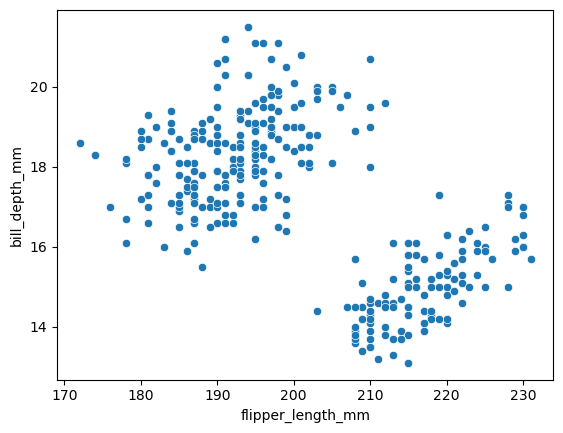

In [102]:
# Task 7 : Scatter Plot: Relationship Between Two Variables

sns.scatterplot(data=dataset, x='flipper_length_mm', y='bill_depth_mm')
plt.show()

# There appears to be a negative relationship between flipper_length_mm and bill_depth_mm

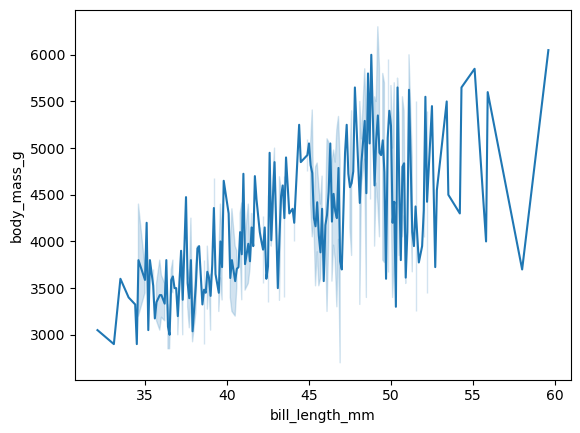

In [112]:
# Task 8 : Line/Area Chart: Trend Across an Ordered Variable
sns.lineplot(data=dataset, x='bill_length_mm', y='body_mass_g')
plt.show()


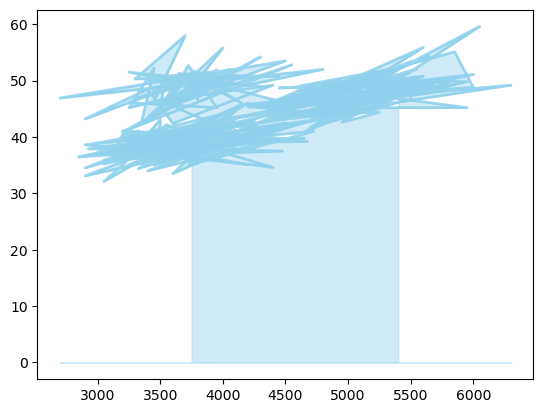

In [113]:
plt.plot(dataset['body_mass_g'], dataset['bill_length_mm'], color="skyblue", alpha=0.8, linewidth=2)
plt.fill_between(dataset['body_mass_g'], dataset['bill_length_mm'], color="skyblue", alpha=0.4)


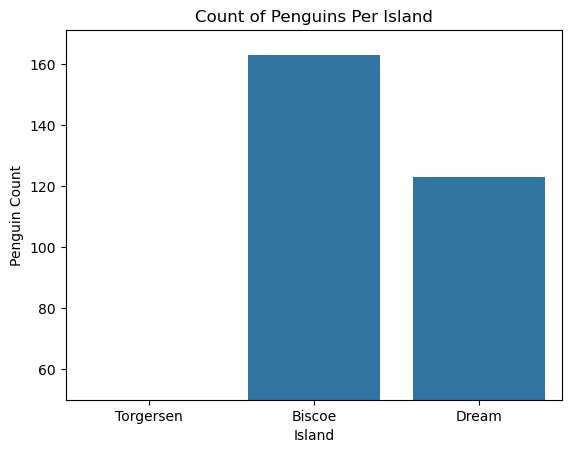

In [114]:
# Task 9 : Graphical Integrity Check

sns.countplot(x='island',data=dataset)
plt.xlabel('Island')
plt.ylabel('Penguin Count')
plt.title("Count of Penguins Per Island")
plt.ylim(bottom=50)
plt.show()
